# Work on - PowerPlant DataSet (Energy Industry)
 ## working steps:
 1. Load the data
 2. Convert the **Data -> Tensors**
 3. For Tensors:
    - Create the **TensorDataset**
    - And **DataLoader**
 4. Define ANN model
 5. Train the model
 6. Final Step: Evaluation

In [1]:
import pandas as pd
import numpy as np

## 1. Load Dataset 

In [3]:
df = pd.read_csv("data/powerplant_data.csv")

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


AT => Temperature  
V => Vacum  
AP => Pressure  
RH => humidity  

PE => Produced energy - **we will Predict this value**

In [7]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

NO any **Null value** present in our deta

In [8]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [9]:
# Split out data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
df.shape

(9568, 5)

In [11]:
# scalling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2. Data -> Tensors
- Tensors -> Pytorch core Data structure
- We convert data to tensors to enable **GPU acceleration**, automatic **gradient computation**, and efficient **multi-dimensional matrix** operations required for neural network training.
- also tensors required by deep learning framworks
- Neural netowk layers expect tensor inputs  
  output = model(tensor_input)

- tensors is like array:
  - 1D -> Scaler
  - 2D -> matrix/vector
  - 3D+ -> **tensors**

- All **tensors** are store in RAM

In [12]:
import torch
import torch.nn as nn

**nn** have all importent funcnality to build the layers,  
like:  
- how many layers we want build
- which layers want to use
- which activation function we want to use
- and more
  
these all things are readily available in **nn**

In [14]:
# creating tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32) # float -> because all scaled value are float
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
# .values -> to convert pandas series to numpy array
# .view(-1, 1) -> to reshape the tensor to have one column and as many rows as needed
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

```
type(X_train_scaled) -> **numpy.ndarray**
type(y_train) -> **pandas.Series**
```
that's why we use y_train.**values** :
- where we were not convert the pd to numpy array by **scaling** => we write **.values**
- and normally don't need to write .values : (where data is in numpy array)

**`.view`(-1, 1):** define the dimension (helps to change shape)
- first par: **rows** , here **-1** - means auto detect
- second par: **cols**

- currently : **y_train** have the 1D shape (n, ) **|** like - [1, 2, 3, ..] 
- but tesnors expected shape is (n, 1) **|** like - [[1], [2], [3] ...]
- thats why we use **.view** to convert the shape to expected tensors

---

## What is the **Neural Network Architecture**  ?
**Neural network architecture** refers to the structural design of an artificial neural network:
- how neurons are organized
- how layers are arrenged
- and how information flows between them.

In deep learning terminology, it defines:
- Number of layers
- Type of layers
- number of neurons per layers
- Activation functions
- Connectivity patters

### NN Architecture for this Dataset
In Dataset
- 4 input fectures -> **4 input layers**

Random architecture:
- **2 hidden layers**
- Each hidden layers have - **6 neurons**

---

## TensorDataset & DataLoader
**DataLoader** - to define how the data will be loaded for training.
- It's create **batches**
- and do **shuffle**(optional)

But a Problem - Data Loader is not able to direct access the raw data from memory.

So we use **TensorDataset** for access the data from memory.

**TensorDataset** - define the dataset
- data access
- one sample/ one row (features, target)

`Tensors` <-- `TensorDataset` <-- `DataLoader`

In [15]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [16]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

--- 

# Deep Learning

### Define our ANN Model

In [17]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        
        self.model = nn.Sequential(
            # No need to define input layer - its auto define by 1st hidden layer
    
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),   # (no. of input, no. output)
    
            #2nd hidden layer
            nn.Linear(6, 6),
    
            # output layer
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

**self**:
- refer to ANN class object
- its define the how to make model inside object
- its based on architecture of Neural network.

**forward()**: - define the forward propogation

**backward:**- auto handle by pytorch
- pytorch have a **Autograd** which handle backward propgation
- **Autograd** is a automatic gradient computation engine.

In [18]:
import torch.optim as optim

model = ANN()

# loss & optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

# Train the ANN
- 

**loss** - loss for 1 batch  
**running loss** - loss for all the batches in 1 epoch

**train losses**: 
- avg-loss per batch (for 1 epoch) =  running loss / # of batches

## Validation
- we can also validate our model with training
- **`model.eval()`** - this help to move training mode -> evaluation mode
- validate on the based of testing data after every epoch

- on testing/validating time don't have any backward prop..
  - work of backward prop. - to adjust the weight/bias (or learnerable param.).
  - but one training is done so that's why now don't need backward prop. again.
  - and also not need to calculate **gradients** and use **optimizers**.

- **`with torch.no_grad()`**
  - this help to don't compute the gradints.
  - it helps to save memory and speed up other computation.

## on each epoch:
- do **training** on training data and **testing** on testing data

In [19]:
# training
train_losses = []
val_losses = []
epochs = 100

best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad() # prevants from accumulate |  used for compute new/fresh gradent every time
        
        outputs =  model(xb) # forward prop... Predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # loss is a tensor => py float data type

    epoch_train_loss = running_loss / len(train_loader)  # avg loss for one epoch
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") # .pt or .pth

epoch 1/100 ==> train loss = 206399.27389322917 & val loss = 204551.515625
epoch 2/100 ==> train loss = 198548.77447916666 & val loss = 187499.90625
epoch 3/100 ==> train loss = 165902.7482421875 & val loss = 137881.984375
epoch 4/100 ==> train loss = 104847.44703776042 & val loss = 70490.546875
epoch 5/100 ==> train loss = 43192.18876953125 & val loss = 20475.125
epoch 6/100 ==> train loss = 9521.070213826497 & val loss = 2675.4111328125
epoch 7/100 ==> train loss = 965.6168379465739 & val loss = 162.08349609375
epoch 8/100 ==> train loss = 65.69646761814754 & val loss = 24.29346466064453
epoch 9/100 ==> train loss = 23.553873805205026 & val loss = 20.61330223083496
epoch 10/100 ==> train loss = 21.881320552031198 & val loss = 20.084814071655273
epoch 11/100 ==> train loss = 21.434262537956236 & val loss = 19.809200286865234
epoch 12/100 ==> train loss = 21.32508986790975 & val loss = 19.689496994018555
epoch 13/100 ==> train loss = 21.145403091112772 & val loss = 19.620450973510742
e

Text(0, 0.5, 'Losses')

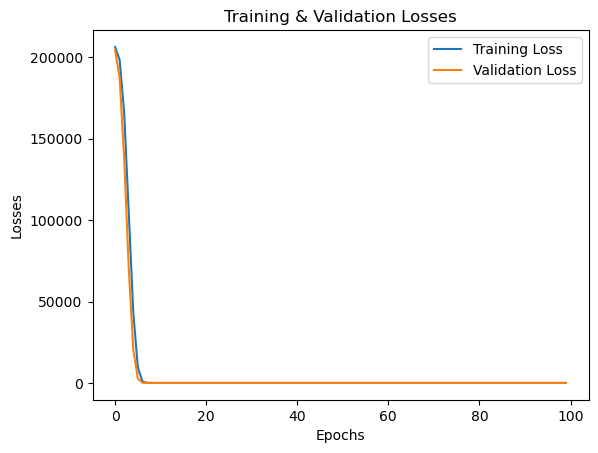

In [ ]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses,
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.title("Training & Validation Losses")
plt.legend()


plt.xlabel("Epochs")
plt.ylabel("Losses")

In [21]:
# Loading the best model
model.load_state_dict(torch.load("model/best_model.pt"))

<All keys matched successfully>

## Evaluation

In [22]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE: ", train_mse_loss.item())
print("Testing MSE: ", test_mse_loss.item())

Training MSE:  21.242952346801758
Testing MSE:  19.549894332885742


In [23]:
from sklearn.metrics import r2_score

print("r^2 socre =", r2_score(y_test, test_preds))

r^2 socre = 0.9316781700751459


In [24]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted values,Actual values
0,435.608185,433.27
1,437.369537,438.16
2,460.947418,458.42
3,475.657013,480.82
4,435.686127,441.41
...,...,...
1909,451.304291,456.70
1910,432.100525,438.04
1911,467.283722,467.80
1912,431.598541,437.14
